In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # importar a classe de normalização
from sklearn.linear_model import LinearRegression # Importando a classe de regressão linear

ENDERECO_DADOS = "https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv"

# Obtendo dados
try:
    print('Obtendo dados...')
    df_ocorrencias = pd.read_csv(ENDERECO_DADOS, sep=';', encoding='iso-8859-1')
    print(df_ocorrencias.head())

except Exception as e:
    print(f'Erro ao obter dados: {e}')

In [ ]:
try:
    print('Delimitando e totalizando as variáveis...')
    df_veiculos = df_ocorrencias[['cisp', 'roubo_veiculo', 'recuperacao_veiculos']]
    df_total_veiculos = df_veiculos.groupby('cisp', as_index=False)[['roubo_veiculo', 'recuperacao_veiculos']].sum()
    print(df_veiculos.head())

except Exception as e:
    print(f'Delimitando as variáveis: {e}')

In [29]:
# Correlação
# import numpy as np

try:
    # Excluindo partes dos valores extremos
    df_total_veiculos_cut = (
        df_total_veiculos[
            df_total_veiculos['roubo_veiculo'] < np.percentile(df_total_veiculos['roubo_veiculo'], 95)
        ]
    )

    df_total_veiculos_cut = (
        df_total_veiculos[
            df_total_veiculos['recuperacao_veiculos'] < np.percentile(df_total_veiculos['recuperacao_veiculos'], 99) # o corte de apenas 1% porque é de um número menor
        ]
    )

    # Criando os arrays em numpy
    array_roubo_veiculo = np.array(df_total_veiculos_cut['roubo_veiculo'])
    array_recuperacao_veiculos = np.array(df_total_veiculos_cut['recuperacao_veiculos'])

    # Calculando correlação
    correlacao = np.corrcoef(array_roubo_veiculo, array_recuperacao_veiculos)[0, 1]
    print(f'Correlação: {correlacao:.6f}')

except Exception as e:
    print(f'Erro ao calcular correlação: {e}')

Correlação: 0.919648


In [30]:
# Regressão Linear

try:
    # Instalar skit-learn
    # pip install scikit-learn
    # from sklearn.model_selection import train_test_split
    print('Regressão Linear...')

    # Separando os dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        array_roubo_veiculo,
        array_recuperacao_veiculos,
        test_size = 0.2,
        random_state = 42
    )

    # importar a classe de normalização
    # from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()

    # Normalizando os dados
    X_train = scaler.fit_transform(X_train.reshape(-1, 1))
    X_test = scaler.transform(X_test.reshape(-1, 1))

    # Importando a classe de regressão linear
    # from sklearn.linear_model import LinearRegression
    # Criando o modelo de regressão linear
    modelo = LinearRegression()

    # Treinando o modelo
    # O modelo aprende os melhores valores de "a" e "b" para a equação y = ax + b
    modelo.fit(X_train, y_train)

    # Coeficiente de determinação
    # Ajuda a determinar se o modelo é confiável
    # R2 = 1 -> modelo perfeito
    # R2 = 0 -> modelo não confiável
    r2_score = modelo.score(X_test, y_test)
    print(f'R² Score: {r2_score}')
    

except Exception as e:
    print(f'Erro ao calcular regressão lienar: {e}')

Regressão Linear...
R² Score: 0.8114709387721548


In [31]:
# Fazendo a previsão para 40.000, 50.000 e 60.000

try:
    array_roubo_veiculo_pred = np.array([40000, 50000, 60000])
    # Dados que eu uso para prever são os dados que eu já tenho, variáveis independentes, ficam no eixo X
    # Normalizando os dados de previsão
    array_roubo_veiculo_pred_scaled = scaler.transform(array_roubo_veiculo_pred.reshape(-1, 1))

    # Fazendo a previsão
    array_roubo_veiculo_pred = modelo.predict(array_roubo_veiculo_pred_scaled)
    print('Previsão dos próximos 3 meses: ', array_roubo_veiculo_pred)

except Exception as e:
    print(f'Erro ao fazer previsão: {e}')

Previsão dos próximos 3 meses:  [25939.38855249 32308.78582087 38678.18308926]


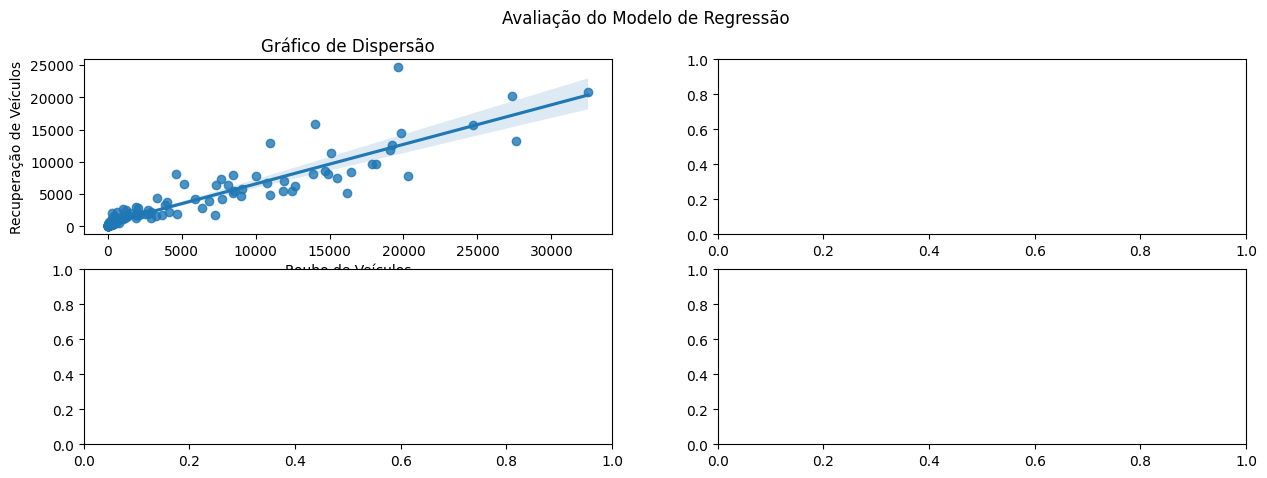

In [32]:
# Avaliando o modelo

try:
    plt.subplots(2, 2, figsize=(15, 5))
    plt.suptitle('Avaliação do Modelo de Regressão')

    plt.subplot(2, 2, 1)
    sns.regplot(x=array_roubo_veiculo, y=array_recuperacao_veiculos)
    plt.title('Gráfico de Dispersão')
    plt.xlabel('Roubo de Veículos')
    plt.ylabel('Recuperação de Veículos')

    plt.subplot(2, 2, 2)
    # testar o modelo com os dados de x_test
    y_pred = modelo.predict(X_test)
    X_test = scaler.inverse_transform(X_test)

    plt.scatter(X_test, y_test, color='blue', label='Dados Reais')
    plt.scatter(X_test, y_pred, color='red', label='Previsões')
    plt.title('Dados Reais vs Previsões')
    plt.xlabel('Roubo de Veículos')
    plt.ylabel('Recuperação de Veículos')

except Exception as e:
    print(f'Erro ao plotar gráfico: {e}')